In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FOLDER = "/content/drive/MyDrive/YOUR_FOLDER"

%cd {FOLDER}

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plot
from torch.utils.data import DataLoader, Subset
from utils import *

# Visualization of the dataset

In [2]:
data_file = "ocean_simulation_data_lite.nc"

Loading ocean_simulation_data.nc for visualization...
Calculating Climatological SST...
Calculating Zonal Mean Stratification...
Extracting Global Mean Time Series at Depths...
Calculating Niño 3.4 Index...


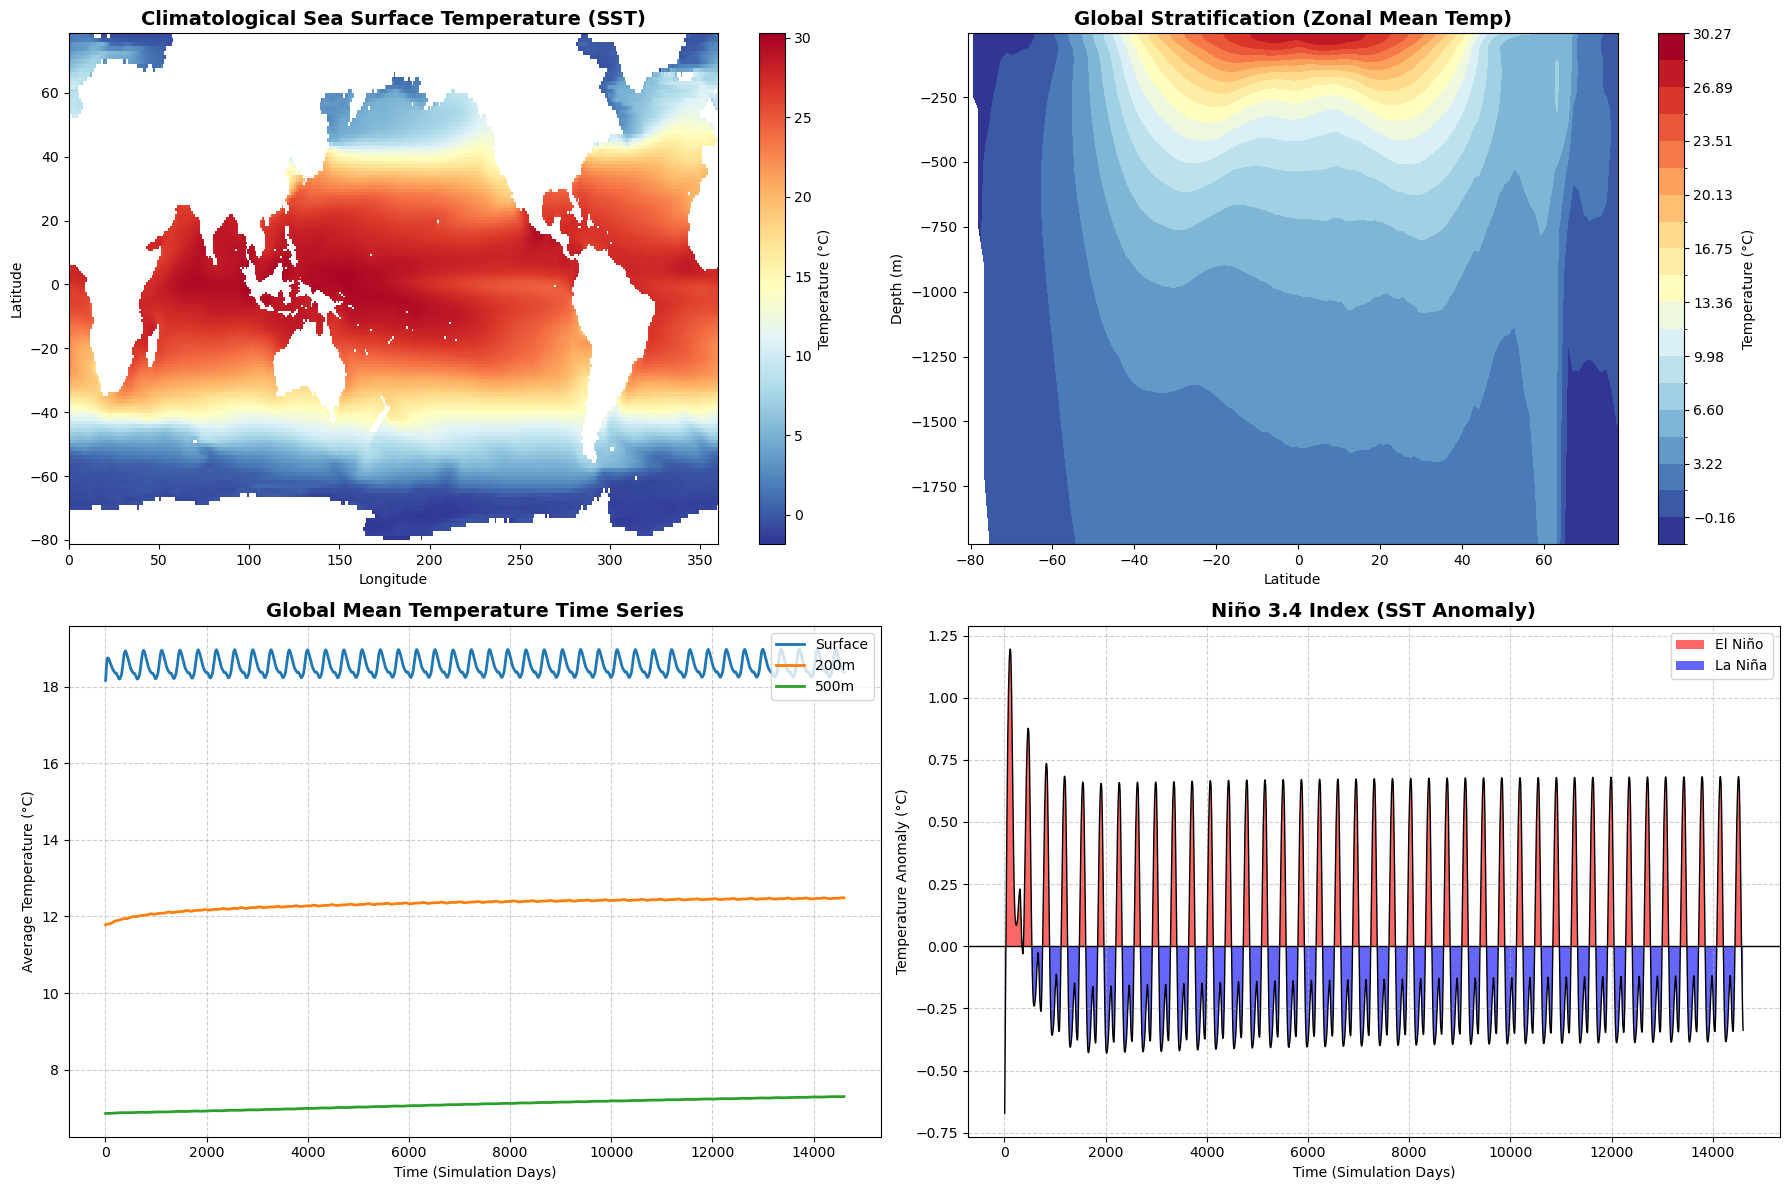

In [3]:
plot_ocean_temperature(data_file)

Loading ocean_simulation_data.nc for dynamics visualization...
Calculating Mean Sea Surface Height...
Calculating Mean Sea Surface Salinity...
Calculating Surface Current Speeds...
Slicing the Equatorial Undercurrent...


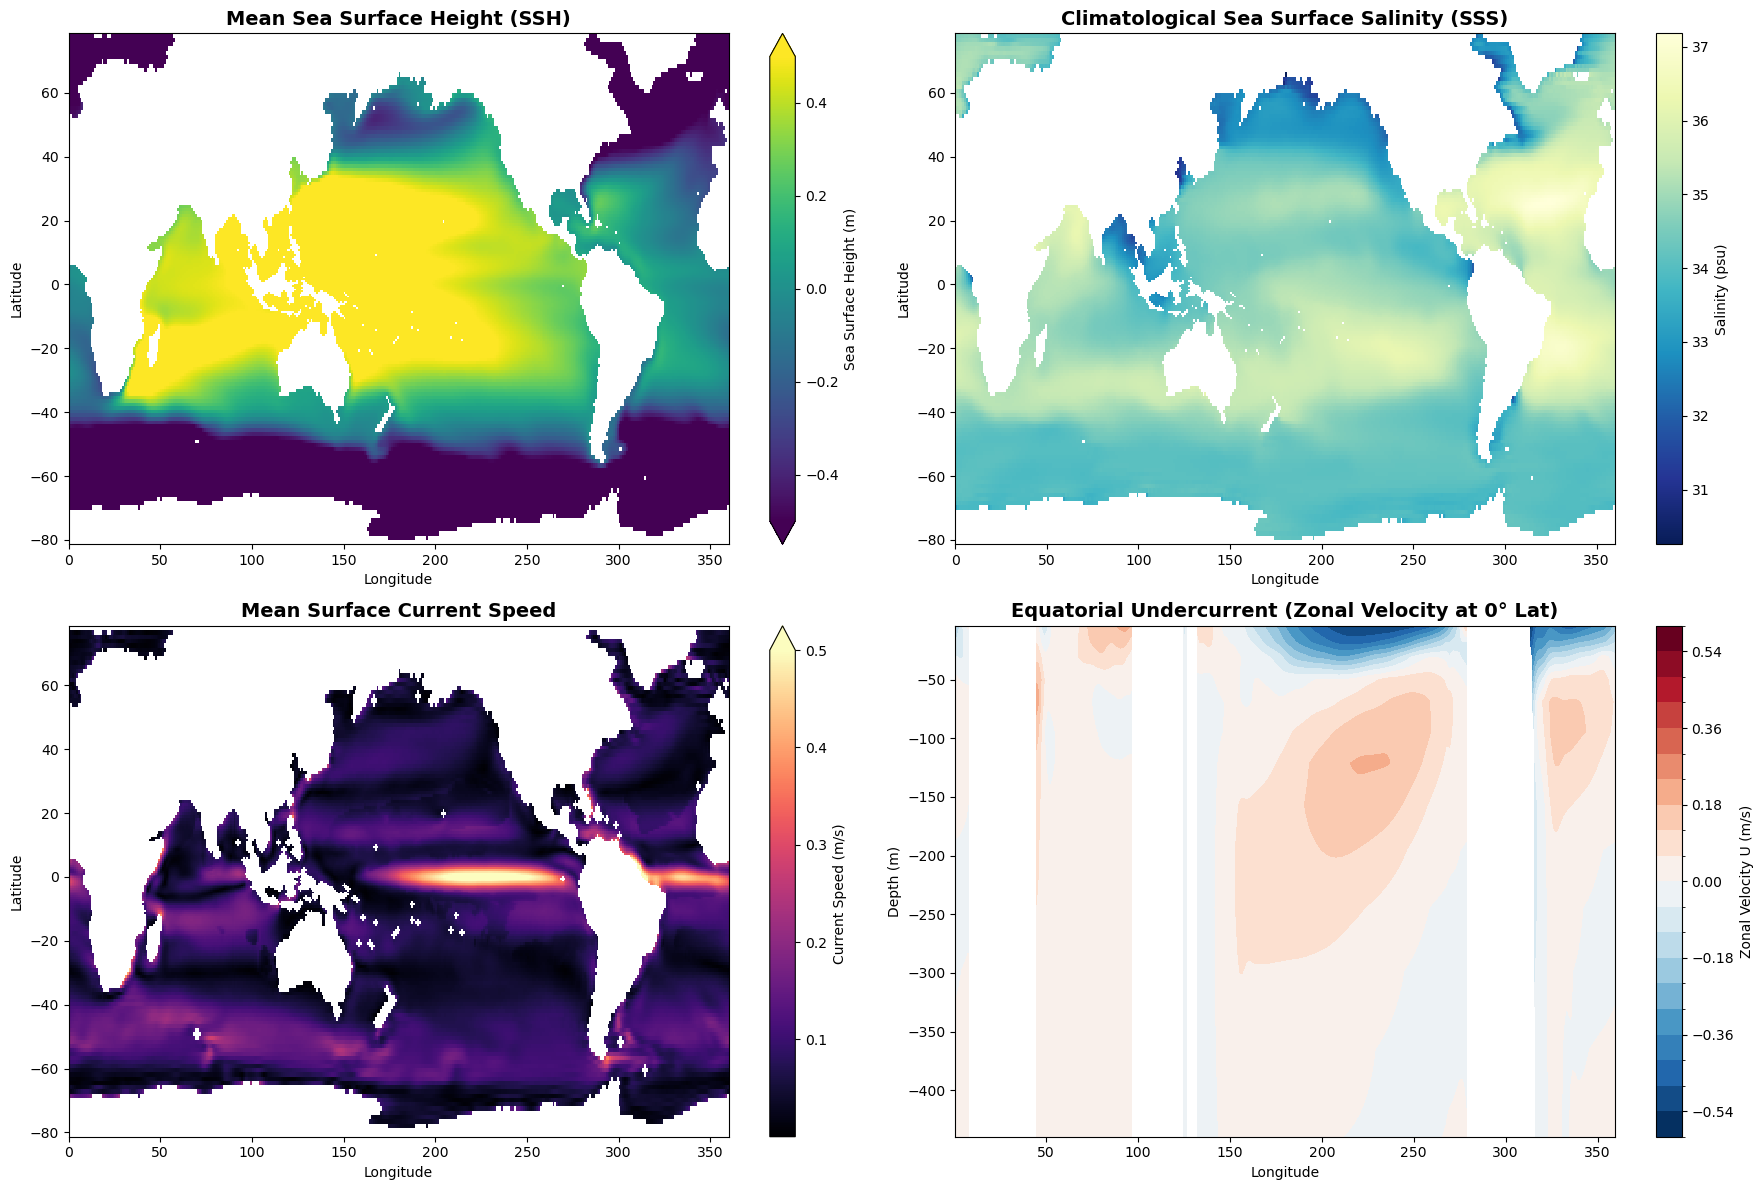

In [4]:
plot_salinity_velocity(data_file)

Loading ocean_simulation_data.nc...
Max Streamfunction in first step: 0.7110906875711743 Sv
Max Streamfunction in last step: 15.041480782397926 Sv


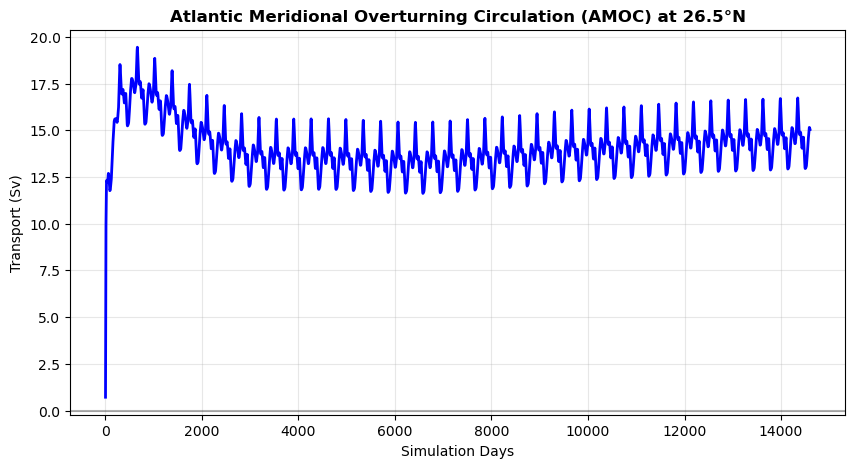

In [5]:
time_days, amoc_timeseries = plot_amoc(data_file)

# Data processing for training

In [6]:
ds = xr.open_dataset(data_file)

In [7]:
ds

<xarray.Dataset> Size: 5GB
Dimensions:            (yt: 160, zt: 22, zw: 22, nmonths: 12, Time: 100, xt: 360)
Coordinates:
  * yt                 (yt) float64 1kB -80.68 -79.32 -77.96 ... 76.6 77.96
  * zt                 (zt) float64 176B -1.973e+03 -1.7e+03 ... -18.28 -4.267
  * zw                 (zw) float64 176B -1.837e+03 -1.58e+03 ... -11.27 0.0
  * nmonths            (nmonths) float64 96B 0.0 1.0 2.0 3.0 ... 9.0 10.0 11.0
  * Time               (Time) timedelta64[ns] 800B 5 days 10 days ... 500 days
  * xt                 (xt) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
Data variables:
    salt               (Time, zt, yt, xt) float64 1GB ...
    temp               (Time, zt, yt, xt) float64 1GB ...
    u                  (Time, zt, yt, xt) float64 1GB ...
    v                  (Time, zt, yt, xt) float64 1GB ...
    ssh                (Time, yt, xt) float64 46MB ...
    surface_taux       (Time, yt, xt) float64 46MB ...
    surface_tauy       (Time, yt, xt) float64 46MB ...
    ml_qnet            (Time, yt, xt) float64 46MB ...
    ml_qsol            (Time, yt, xt) float64 46MB ...
    ml_qneq            (Time, yt, xt) float64 46MB ...
    forc_temp_surface  (Time, yt, xt) float64 46MB ...
    temp_source        (Time, zt, yt, xt) float64 1GB ...
Attributes:
    date_created:       2026-03-13T14:37:38.820273
    veros_version:      0+untagged.1791.g667fe53.dirty
    setup_identifier:   /scratch/so2495/data/numerical_simulations/veros_outp...
    setup_description:  Global Ocean Configuration setup
    setup_settings:     {"identifier": "/scratch/so2495/data/numerical_simula...
    setup_file:         None
    setup_code:         UNKNOWN

In [8]:
dataset = OceanDataset(ds, input_steps=1, target_steps=5, normalize=True)

n_total = len(dataset)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

# --- sequential split ---
train_ds = Subset(dataset, range(0, n_train))
val_ds   = Subset(dataset, range(n_train, n_train + n_val))
test_ds  = Subset(dataset, range(n_train + n_val, n_total))

# --- dataloaders ---
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False)

print(f"Total samples : {n_total}")
print(f"Train samples : {len(train_ds)}")
print(f"Val   samples : {len(val_ds)}")
print(f"Test  samples : {len(test_ds)}")

initializing ocean dataset
Total samples : 95
Train samples : 66
Val   samples : 14
Test  samples : 15


In [9]:
# check shapes
batch = next(iter(train_loader))
print(batch['state_2d'].shape)   # (batch_size, input_steps, n_vars_1d, yt, xt)
print(batch['state_3d'].shape)   # (batch_size, input_steps, n_vars_3d, zt, yt, xt)
print(batch['forcings'].shape)   # (batch_size, input_steps+target_steps, n_forcings, yt,  xt)
print(batch['target_3d'].shape)  # (batch_size, target_steps, n_vars_3d, zt, yt,  xt)
print(batch['target_2d'].shape)  # (batch_size, target_steps, n_vars_2d, yt,  xt)

torch.Size([8, 1, 1, 160, 360])
torch.Size([8, 1, 4, 22, 160, 360])
torch.Size([8, 6, 4, 160, 360])
torch.Size([8, 5, 4, 22, 160, 360])
torch.Size([8, 5, 1, 160, 360])


# Construct a CNN model

# Training/validation loop

# Test set evaluation 

# Autoregressive rollout